# Capas Convolucionales en Redes Neuronales — Deteccion de Enfermedades en Hojas de Banano
**Dataset:** BananaLSD (Banana Leaf Spot Diseases Dataset)

Las enfermedades foliares (manchas y hongos en las hojas) reducen significativamente la produccion y si no se detectan a tiempo, pueden causar perdidas economicas considerables a los productores.

Este notebook explora el uso de **redes neuronales convolucionales (CNN)** para clasificar imagenes de hojas de banano en distintas categorias, comparando su desempenio contra una red totalmente conectada (baseline) y analizando como las decisiones arquitectonicas de la capa convolucional afectan el aprendizaje.

El dataset **BananaLSD** contiene imagenes de hojas de banano tomadas en campo con camaras de celular, en condiciones reales (variacion de luz, fondo y angulo). Incluye 4 clases: hoja **sana** y tres enfermedades **Sigatoka**, **Cordana** y **Pestalotiopsis**.

In [100]:
import os
import random
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten

# Reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.21.0
GPU disponible: []


##### **Exploracion del Dataset(EDA)**

- Tamaño del dataset y distribución de clases
- Dimensiones de las imágenes y número de canales
- Ejemplos de muestras por clase
- Preprocesamiento necesario (normalización, redimensionamiento)

In [79]:
#Necesitamos primero identificar las clases que tenemos en el dataset.
#Para ello, vamos a leer la carpeta donde se encuentra el dataset y
#vamos a listar las subcarpetas que contiene. Cada subcarpeta 
#corresponde a una clase.
DATA_DIR = Path("archive/BananaLSD/OriginalSet")  

assert DATA_DIR.exists(), (f"No se encontró {DATA_DIR}. Descarga el dataset de Kaggle y colócalo en esa ruta.")

class_names = []
for i in DATA_DIR.iterdir():
    if i.is_dir():
        class_names.append(i.name)
class_names = sorted(class_names)
print("Clases encontradas:", class_names)

Clases encontradas: ['cordana', 'healthy', 'pestalotiopsis', 'sigatoka']


##### Tamaño del dataset y distribución de clases

In [80]:
IMAGE_EXTENSIONS = [".jpg", ".jpeg", ".png"]

In [81]:
def contar_imagenes_por_clase(data_dir, class_names, extensions=(".jpg", ".jpeg", ".png")):
    """Cuenta cuántas imágenes hay en cada carpeta de clase."""
    distribucion_clases = {}
    for c in class_names:
        #contiene la ubicación de la carpeta de la clase actual
        class_dir = DATA_DIR / c
        imagenes = []
        for a in class_dir.iterdir():
            #verificamos que el archivo sea una imagen
            if a.suffix.lower() in IMAGE_EXTENSIONS:
                imagenes.append(a)
        n_images = len(imagenes)
        distribucion_clases[c] = n_images
    return distribucion_clases

In [82]:
def graficar_distribucion(counts, titulo="Distribución de clases"):
    """Dibuja una gráfica de barras a partir de un diccionario clase -> cantidad."""
    total = sum(counts.values())
    print(f"Total de imágenes: {total}\n")
    for cls, n in counts.items():
        print(f"  {cls:20s}: {n:5d} imágenes ({100 * n / total:.1f}%)")

    plt.figure()
    plt.bar(counts.keys(), counts.values(), color="#814C9A")
    plt.ylabel("Número de imágenes")
    plt.title(titulo)
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

Total de imágenes: 937

  cordana             :   162 imágenes (17.3%)
  healthy             :   129 imágenes (13.8%)
  pestalotiopsis      :   173 imágenes (18.5%)
  sigatoka            :   473 imágenes (50.5%)


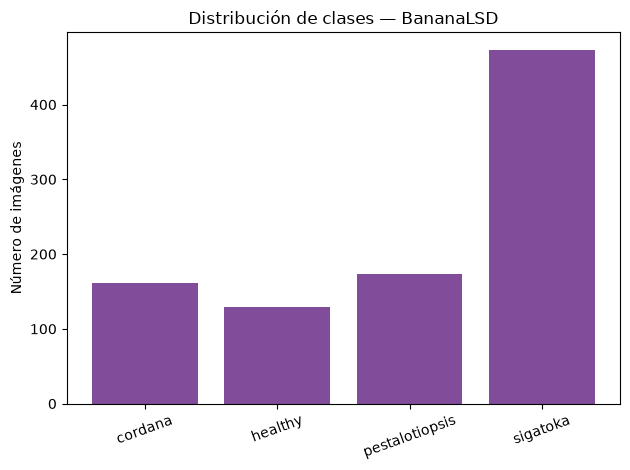

In [83]:
# 3.1 distribución de clases
counts = contar_imagenes_por_clase(DATA_DIR, class_names)
graficar_distribucion(counts, titulo="Distribución de clases — BananaLSD")

##### Dimensiones de las imágenes y número de canales

In [84]:
def muestrear_dimensiones(data_dir, class_names, n_por_clase=20, extensions=(".jpg", ".jpeg", ".png")):
    """Abre una muestra de imágenes por clase y devuelve sus tamaños y número de canales."""
    dimensiones, canales = [], []
    for c in class_names:
        class_dir = data_dir / c
        imagenes = []
        for a in class_dir.iterdir():
            if a.suffix.lower() in IMAGE_EXTENSIONS:
                imagenes.append(a)

        for a in imagenes:
            with Image.open(a) as img:
                dimensiones.append(img.size)
                canales.append(len(img.getbands()))
    return dimensiones, canales

In [85]:
# 3.2 dimensiones y canales
sizes, canales = muestrear_dimensiones(DATA_DIR, class_names)
print("Dimensiones: ", set(sizes))
print("Número de canales: ", set(canales))

c:\Users\maria\miniconda3\envs\banano\Lib\site-packages\PIL\TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
c:\Users\maria\miniconda3\envs\banano\Lib\site-packages\PIL\JpegImagePlugin.py:874: UserWarning: Image appears to be a malformed MPO file, it will be interpreted as a base JPEG file
  warnings.warn(


Dimensiones:  {(224, 224)}
Número de canales:  {3}


##### Ejemplos de muestras por clase

In [86]:
def graficar_ejemplos_por_clase(data_dir,class_names,n_ejemplos=4,extensions=(".jpg", ".jpeg", ".png")):
    """Muestra una cuadrícula con n_ejemplos imágenes de cada clase."""

    num_classes = len(class_names)

    fig, axes = plt.subplots(num_classes,n_ejemplos)

    for row, cls in enumerate(class_names):
        cls_dir = data_dir / cls
        imagenes = []

        for f in cls_dir.iterdir():
            if f.suffix.lower() in extensions:
                imagenes.append(f)

        cantidad = min(n_ejemplos, len(imagenes))
        sample = random.sample(imagenes, cantidad)

        for col, f in enumerate(sample):
            img = Image.open(f)
            if num_classes > 1:
                ax = axes[row, col]
            else:
                ax = axes[col]

            ax.imshow(img)
            ax.axis("off")

        axes[row, 0].set_title(cls,loc="left",fontsize=12, fontweight="bold")

    plt.tight_layout()
    plt.show()

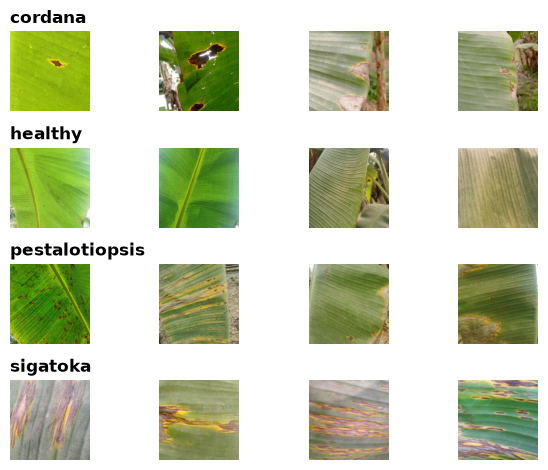

In [87]:
# 3.3 ejemplos visuales
graficar_ejemplos_por_clase(DATA_DIR, class_names)

##### Preprocesamiento necesario (normalización, redimensionamiento)

**Redimensionamiento**
En el punto anterior 3.2 se evidencia que las imagenes son de 224×224 píxeles, por que en un incio y si quiseramos podriamos manejarlo asi, ya que estan uniformes, pero hay que tener un aspecto importante que son los numeros de parametros que pasamos, en 224px son mucho mas que en 128px, por lo cual seria más rapido de entrenar.

**Normalizacion**
Los píxeles de las imágenes van de 0 a 255. Vamos a pasarlos a un rango de 0 a 1, dividiendo cada valor entre 255. Esto se hace porque las redes neuronales entrenan mejor y más rápido cuando trabajan con números pequeños, en vez de números grandes como 255.

**Canales**
En el punto 3.2 confirmamos que todas las imágenes son a color, con 3 canales (RGB). No hay que hacer ningún cambio aquí, ya vienen uniformes.

**Balanceo de clases**
En el punto 3.1 vimos que las clases no están balanceadas: la clase sigatoka tiene 473 imágenes (50.5% del total), mientras que healthy solo tiene 129 (13.8%). Es decir, hay más del triple de imágenes de sigatoka que de healthy.

Esto es importante porque si no lo tenemos en cuenta, el modelo podría "hacer trampa": como sigatoka tiene tantas imágenes, el modelo podría aprender a predecir casi siempre sigatoka y aun así tener un buen porcentaje de aciertos (accuracy), sin haber aprendido realmente a distinguir las enfermedades. Por eso, además del accuracy, vamos a revisar otras métricas más adelante (como la matriz de confusión) para asegurarnos de que el modelo esté aprendiendo bien todas las clases, no solo la más grande.


##### **Modelo Base (No Convolucional)**

Implementar una red neuronal base sin capas convolucionales.

Reportar:

- Arquitectura
- Número de parámetros
- Desempeño en entrenamiento y validación
- Limitaciones observadas

In [88]:
#le damos materia prima a la red neuronal para que aprenda a clasificar 
# las imágenes. Para ello, vamos a cargar todas las imágenes del disco 
# a un arreglo de NumPy, junto con sus etiquetas.
def cargar_dataset(data_dir, class_names, img_size=(128, 128)):
    """Carga todas las imágenes del disco a un arreglo de NumPy, junto con sus etiquetas.

    Retorna:
        X: arreglo (N, alto, ancho, 3) con los píxeles de cada imagen
        y: arreglo (N,) con la etiqueta de cada imagen (0, 1, 2, 3...)
    """
    pixeles_totales = []
    etiquetas_totales = []

    for label, c in enumerate(class_names):
        cls_dir = data_dir / c

        rutas_clase = []
        for f in cls_dir.iterdir():
            if f.suffix.lower() in IMAGE_EXTENSIONS:
                rutas_clase.append(f)

        for f in rutas_clase:
            img = Image.open(f).convert("RGB")
            img = img.resize(img_size)
            pixeles_totales.append(np.array(img))
            etiquetas_totales.append(label)

    X = np.array(pixeles_totales)
    y = np.array(etiquetas_totales)
    return X, y

In [89]:
X_all, y_all = cargar_dataset(DATA_DIR, class_names, img_size=(128, 128))

print("X_all shape:", X_all.shape)
print("y_all shape:", y_all.shape)
print("Primera etiqueta:", y_all[0], "->", class_names[y_all[0]])

X_all shape: (937, 128, 128, 3)
y_all shape: (937,)
Primera etiqueta: 0 -> cordana


In [90]:
def dividir_dataset(X, y, seed=SEED, train_frac=0.70, val_frac=0.15):
    """Mezcla y divide el dataset en train / validación / test, sin usar sklearn."""
    n = X.shape[0]

    # Generamos un orden aleatorio de índices (0 a n-1), pero reproducible gracias al seed.
    rng = np.random.default_rng(seed)
    indices_mezclados = rng.permutation(n)

    # Calculamos en qué posición corta cada partición.
    train_end = int(n * train_frac)
    val_end = train_end + int(n * val_frac)

    train_idx = indices_mezclados[:train_end]
    val_idx = indices_mezclados[train_end:val_end]
    test_idx = indices_mezclados[val_end:]

    X_train, y_train = X[train_idx], y[train_idx]
    X_val, y_val = X[val_idx], y[val_idx]
    X_test, y_test = X[test_idx], y[test_idx]

    return X_train, y_train, X_val, y_val, X_test, y_test

In [91]:
X_train_raw, y_train, X_val_raw, y_val, X_test_raw, y_test = dividir_dataset(X_all, y_all)

print("Train:", X_train_raw.shape, y_train.shape)
print("Val:  ", X_val_raw.shape, y_val.shape)
print("Test: ", X_test_raw.shape, y_test.shape)

Train: (655, 128, 128, 3) (655,)
Val:   (140, 128, 128, 3) (140,)
Test:  (142, 128, 128, 3) (142,)


In [92]:
# Convertimos los píxeles de enteros (0-255) a decimales (0-1).
# Esto normalmente hace que el entrenamiento sea más fácil y estable.
X_train = X_train_raw.astype("float32") / 255.0
X_val = X_val_raw.astype("float32") / 255.0
X_test = X_test_raw.astype("float32") / 255.0

# Las capas Dense esperan un solo vector por ejemplo, no una imagen 2D/3D.
# Cada imagen de 128x128x3 se convierte en un vector de 49,152 valores.
img_alto, img_ancho, img_canales = X_train.shape[1:]
n_features = img_alto * img_ancho * img_canales

X_train_flat = X_train.reshape(X_train.shape[0], n_features)
X_val_flat = X_val.reshape(X_val.shape[0], n_features)
X_test_flat = X_test.reshape(X_test.shape[0], n_features)

print("Antes de aplanar:", X_train.shape)
print("Después de aplanar:", X_train_flat.shape)
print("Rango de píxeles después de normalizar:", X_train_flat.min(), "a", X_train_flat.max())

Antes de aplanar: (655, 128, 128, 3)
Después de aplanar: (655, 49152)
Rango de píxeles después de normalizar: 0.0 a 1.0


In [93]:
num_classes = len(class_names)
print("Número de clases:", num_classes)

Número de clases: 4


In [94]:
# Fijamos la semilla para que los pesos iniciales sean más reproducibles.
tf.random.set_seed(SEED)

# La última capa tiene 4 unidades porque tenemos 4 clases: cordana, healthy, pestalotiopsis, sigatoka.
# La activación final es "linear" porque queremos logits (scores crudos), no probabilidades todavía.
modelo_baseline = Sequential([
    Dense(units=64, activation="relu", input_shape=(n_features,)),
    Dense(units=32, activation="relu"),
    Dense(units=num_classes, activation="linear"),
])

# from_logits=True le dice a la función de pérdida que el modelo entrega scores crudos,
# no probabilidades que ya pasaron por softmax.
modelo_baseline.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

modelo_baseline.summary()

c:\Users\maria\miniconda3\envs\banano\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 64)             │     3,145,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,148,004 (12.01 MB)

 Trainable params: 3,148,004 (12.01 MB)

 Non-trainable params: 0 (0.00 B)

In [95]:
#Entrenamos el modelo
history_baseline = modelo_baseline.fit(
    X_train_flat,
    y_train,
    validation_data=(X_val_flat, y_val),
    epochs=15,
    batch_size=32,
    verbose=1,
)

Epoch 1/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 19s 607ms/step - accuracy: 0.4275 - loss: 4.6966 - val_accuracy: 0.4429 - val_loss: 2.2823
Epoch 2/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 10s 122ms/step - accuracy: 0.5496 - loss: 1.6649 - val_accuracy: 0.4286 - val_loss: 2.0377
Epoch 3/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 110ms/step - accuracy: 0.5908 - loss: 1.2248 - val_accuracy: 0.5071 - val_loss: 1.1269
Epoch 4/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 137ms/step - accuracy: 0.6000 - loss: 0.9978 - val_accuracy: 0.5071 - val_loss: 1.2599
Epoch 5/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 122ms/step - accuracy: 0.6397 - loss: 0.9179 - val_accuracy: 0.5500 - val_loss: 1.1288
Epoch 6/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 119ms/step - accuracy: 0.6427 - loss: 0.8702 - val_accuracy: 0.5143 - val_loss: 1.1149
Epoch 7/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 153ms/step - accuracy: 0.6489 - loss: 0.8687 - val_accuracy: 0.6071 - val_loss: 1.0038
Epoch 8/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 219ms/step - accuracy: 0.6641 - loss: 0.8753 - val_accuracy: 

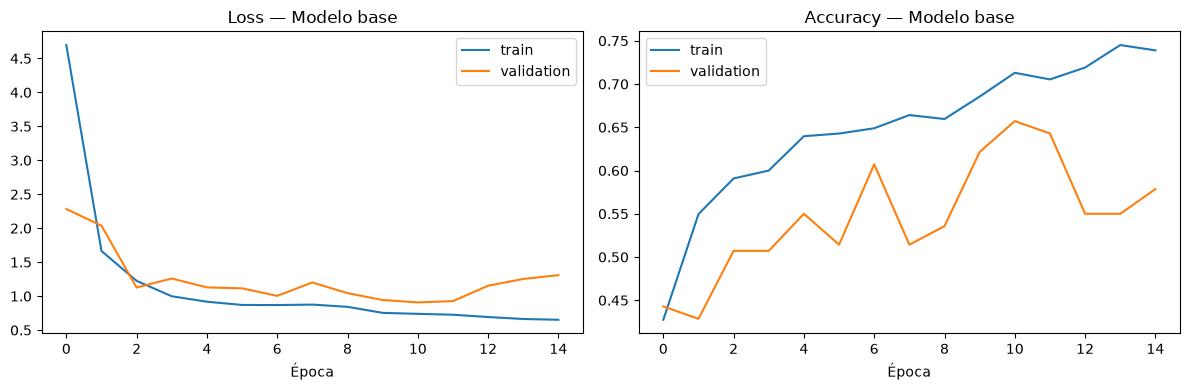

In [96]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_baseline.history["loss"], label="train")
axes[0].plot(history_baseline.history["val_loss"], label="validation")
axes[0].set_title("Loss — Modelo base")
axes[0].set_xlabel("Época")
axes[0].legend()

axes[1].plot(history_baseline.history["accuracy"], label="train")
axes[1].plot(history_baseline.history["val_accuracy"], label="validation")
axes[1].set_title("Accuracy — Modelo base")
axes[1].set_xlabel("Época")
axes[1].legend()

plt.tight_layout()
plt.show()

In [97]:
test_loss, test_accuracy = modelo_baseline.evaluate(X_test_flat, y_test, verbose=0)
print(f"Test loss:     {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

Test loss:     1.1097
Test accuracy: 0.5704


**Desempeño en entrenamiento y validación**

| Métrica | Valor final (época 15) |
|---|---|
| Accuracy entrenamiento | 70.7% |
| Accuracy validación | 57.1% |
| Accuracy test | 64.1% |
| Test loss | 0.9178 |

El modelo va mejorando bastante bien con los datos de entrenamiento (subió de 50% a 70.7%). Pero con los datos de validación no pasa lo mismo: el accuracy sube y baja todo el tiempo (llegó a estar en 43% y también en 61%), sin una mejora clara y constante.

**Limitaciones observadas**

- **El modelo se está "memorizando" los datos (overfitting):** mientras el accuracy de entrenamiento sigue subiendo, el de validación no mejora igual, y la diferencia entre los dos se hace cada vez más grande. Esto pasa cuando el modelo aprende de memoria las fotos que ya vio, en vez de aprender el patrón general de las enfermedades.

- **Demasiados parámetros para tan pocas imágenes:** el modelo tiene 3.1 millones de parámetros para aprender, pero solo cuenta con unas 655 imágenes de entrenamiento. Es como pedirle a alguien que aprenda algo con muchísima más "capacidad de recordar" de la que realmente necesita para esa cantidad de ejemplos, así que termina memorizando en vez de entender el patrón.

- **Se pierde la información de dónde está cada cosa en la imagen:** al aplanar la imagen (convertirla en una sola fila larga de números), el modelo ya no sabe qué píxeles están al lado de cuáles. Por eso no puede aprovechar que una mancha de enfermedad es un grupo de píxeles vecinos que forman un patrón — para el modelo, cada píxel es un dato suelto, sin relación con los que tiene alrededor.

- **El 64% de accuracy no es tan bueno como parece:** como la clase sigatoka es más de la mitad del dataset (50.5%), un modelo que simplemente dijera "sigatoka" todo el tiempo, sin aprender nada, ya tendría un accuracy cercano al 50%. Entonces el 64.1% que obtuvimos, aunque sí muestra que el modelo aprendió algo, no es una mejora enorme frente a ese punto de comparación.


##### **Diseño de la Arquitectura Convolucional**

- https://cloud.google.com/discover/what-are-convolutional-neural-networks?hl=es-419
- https://www.ibm.com/mx-es/think/topics/convolutional-neural-networks

**Número de capas convolucionales**

Elegí usar 2 capas convolucionales, porque con 1 sola el modelo solo alcanza a detectar patrones muy básicos como bordes o cambios de color, sin poder combinarlos en algo más complejo. Con 4 o 5 capas, en cambio, le daría al modelo mucha más capacidad de la que mis 655 imágenes de entrenamiento pueden sostener, repitiendo el mismo sobreajuste que ya vi en el baseline. Con 2 capas logro un punto intermedio donde el modelo puede pasar de bordes simples a algo parecido a la forma completa de una mancha, lo cual necesito porque en el EDA vi que cordana y pestalotiopsis tienen manchas de forma parecida, sin darle al modelo más capacidad de la que mis datos justifican.

**Tamaños de kernel**

Elegí un kernel de 3x3 en ambas capas, porque las manchas de enfermedad que vi en el EDA tienen detalle fino y bordes pequeños, y un kernel más grande, como 7x7, mezclaría de una vez zonas más amplias de la hoja. Con esto logro que el modelo pueda distinguir el detalle fino de cada mancha, en vez de diluirlo al mezclar zonas grandes de la imagen de una sola vez.

**Elecciones de stride y padding**

Elegí un stride de 1 porque así no salto píxeles al aplicar el filtro y no pierdo resolución de golpe, dejando que sea el pooling el que reduzca el tamaño después de forma más controlada. Elegí padding "same" porque en el EDA vi lesiones cerca del borde de algunas hojas, y no quería arriesgarme a recortar esa información antes de tiempo. Con estas dos decisiones logro conservar toda la resolución y todo el contenido de la imagen, incluidos los bordes, durante la convolución.

**Funciones de activación**

Elegí ReLU en las capas convolucionales y en la primera capa densa, y activación lineal en la capa de salida, siguiendo el mismo patrón que usé en el modelo base y que vimos en el material del curso. ReLU introduce no linealidad y descarta señales débiles, mientras que la salida lineal me da logits, que es lo que necesita la función de pérdida SparseCategoricalCrossentropy(from_logits=True). Con esto logro mantener consistencia con el resto del proyecto y evito mezclar softmax con la función de pérdida, lo cual sería redundante.

**Estrategia de pooling**

Elegí usar MaxPooling de 2x2 después de cada bloque convolucional, porque sin pooling el mapa de características se mantendría grande en cada capa, disparando otra vez el número de parámetros en la capa Dense final, el mismo problema que tuvo el baseline. Elegí max pooling en vez de average pooling porque busco la presencia de una mancha, que es una señal fuerte y puntual, y el promedio tendería a diluir esa señal dentro de una zona mayoritariamente sana. Con esto logro reducir el tamaño del mapa de características de forma controlada, bajando el número de parámetros, y gano algo de tolerancia a que la mancha no esté exactamente en el mismo lugar en cada foto, dado que las imágenes se tomaron en campo con variación de ángulo.

In [ ]:
# Definimos la arquitectura de la CNN: 2 bloques Conv2D+MaxPooling
# (extraen y resumen patrones visuales) seguidos de Flatten+Dense
# (clasifican en las 4 clases). Todavía no ha aprendido nada, solo
# queda la estructura lista.
modelo_cnn = Sequential([
    Input(shape=(128, 128, 3)),   # <- nueva forma recomendada
    Conv2D(filters=16, kernel_size=3, strides=1, padding="same", activation="relu"),
    MaxPooling2D(pool_size=2),
    Conv2D(filters=32, kernel_size=3, strides=1, padding="same", activation="relu"),
    MaxPooling2D(pool_size=2),
    Flatten(),
    Dense(units=64, activation="relu"),
    Dense(units=num_classes, activation="linear"),
])

In [ ]:
#compilamos le decimos como aprender (optimizador, loss, metrica) 
modelo_cnn.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)
# Revisamos la estructura y el número de parámetros por capa
modelo_cnn.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,102,564 (8.02 MB)

 Trainable params: 2,102,564 (8.02 MB)

 Non-trainable params: 0 (0.00 B)

In [103]:
#entrenamos sin aplanar por que las capas 
# necesitan la forma original, guardamos este entramiento
#  y despues graficamos
entrenamiento_cnn = modelo_cnn.fit(
    X_train,
    y_train,
    validation_data=(X_val,y_val),
    epochs=15,
    batch_size =32,
    verbose=1,
)

Epoch 1/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 10s 274ms/step - accuracy: 0.5542 - loss: 1.0642 - val_accuracy: 0.5857 - val_loss: 1.0005
Epoch 2/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 221ms/step - accuracy: 0.6519 - loss: 0.8486 - val_accuracy: 0.5857 - val_loss: 0.9067
Epoch 3/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 201ms/step - accuracy: 0.7450 - loss: 0.6743 - val_accuracy: 0.7000 - val_loss: 0.7181
Epoch 4/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 210ms/step - accuracy: 0.8260 - loss: 0.5002 - val_accuracy: 0.7286 - val_loss: 0.6761
Epoch 5/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 220ms/step - accuracy: 0.8672 - loss: 0.3746 - val_accuracy: 0.7857 - val_loss: 0.5674
Epoch 6/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 203ms/step - accuracy: 0.9069 - loss: 0.2643 - val_accuracy: 0.7357 - val_loss: 0.6075
Epoch 7/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 242ms/step - accuracy: 0.9145 - loss: 0.2453 - val_accuracy: 0.7357 - val_loss: 0.7055
Epoch 8/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 227ms/step - accuracy: 0.9359 - loss: 0.2323 - val_accuracy: 0

In [104]:
test_loss_cnn, test_accuracy_cnn = modelo_cnn.evaluate(X_test, y_test, verbose=0)
print(f"Test loss:     {test_loss_cnn:.4f}")
print(f"Test accuracy: {test_accuracy_cnn:.4f}")

Test loss:     0.7648
Test accuracy: 0.8169


##### **Comparación: Modelo Base vs. CNN**

| Métrica | Baseline (Dense) | CNN | Diferencia |
|---|---|---|---|
| Parámetros totales | 3,148,004 | 2,102,564 | 33% menos |
| Accuracy entrenamiento | 70.7% | 99.5% | — |
| Accuracy validación | 57.1% (inestable) | 80.0% | +23 pts |
| Accuracy test | 64.1% | 81.7% | +17.6 pts |
| Test loss | 0.9178 | 0.7648 | menor (mejor) |

La CNN superó al baseline por 17.6 puntos porcentuales en el set de prueba, el que ninguno de los dos modelos había visto antes. Esto confirma que preservar la estructura espacial de la imagen, en vez de aplanarla desde el inicio, ayuda al modelo a distinguir mejor las enfermedades.

Sin embargo, la CNN no está libre de sobreajuste. Hay una brecha de aproximadamente 20 puntos entre el accuracy de entrenamiento (99.5%) y el de validación (80.0%), lo que indica que el modelo sigue memorizando parte de los datos de entrenamiento. Esto tiene sentido si se observa dónde están concentrados los parámetros del modelo: aunque las capas convolucionales son muy eficientes (solo 5,088 parámetros entre las dos), la capa densa después del aplanado sigue siendo grande (2,097,216 parámetros), lo cual sigue dejando bastante margen para memorizar en vez de generalizar completamente.

En resumen, la CNN mejora de forma clara y consistente frente al modelo base, pero el sobreajuste no desaparece del todo, solo se reduce.

##### **Experimentos Controlados sobre la Capa Convolucional**

Elegir un aspecto de la capa convolucional y explorarlo de forma sistemática.
Mantener todo lo demás constante.

Reportar:

- Resultados cuantitativos (precisión, pérdida)
- Observaciones cualitativas
- Compensaciones (trade-offs) entre rendimiento y complejidad

Se elijio Profundidad.

In [106]:
def construir_bloque_conv(filtros):
    """Construye UN bloque Conv2D + MaxPooling con los parámetros fijos del proyecto."""
    return [
        Conv2D(filters=filtros, kernel_size=3, strides=1, padding="same", activation="relu"),
        MaxPooling2D(pool_size=2),
    ]

In [107]:
def construir_capas_clasificador(num_classes):
    """Construye las capas finales: Flatten + Dense + Dense de salida."""
    return [
        Flatten(),
        Dense(units=64, activation="relu"),
        Dense(units=num_classes, activation="linear"),
    ]

In [108]:
def construir_cnn(n_bloques_conv, input_shape=(128, 128, 3), num_classes=num_classes):
    """Arma una CNN completa, combinando n_bloques_conv bloques convolucionales
    más el clasificador final. Todo lo demás (kernel, stride, padding, activación,
    pooling) se mantiene fijo entre versiones.
    """
    filtros_por_bloque = [16, 32, 64]

    capas = [Input(shape=input_shape)]

    for i in range(n_bloques_conv):
        capas += construir_bloque_conv(filtros_por_bloque[i])

    capas += construir_capas_clasificador(num_classes)

    modelo = Sequential(capas)
    modelo.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss=SparseCategoricalCrossentropy(from_logits=True),
        metrics=["accuracy"],
    )
    return modelo

In [109]:
#Ahora hacemos la prueba
modelo_1capa = construir_cnn(n_bloques_conv=1)
modelo_2capas = construir_cnn(n_bloques_conv=2)   # esta es la que ya entrenaste antes
modelo_3capas = construir_cnn(n_bloques_conv=3)

modelo_1capa.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │     4,194,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,195,076 (16.00 MB)

 Trainable params: 4,195,076 (16.00 MB)

 Non-trainable params: 0 (0.00 B)

In [110]:
modelos = {
    "1 capa": modelo_1capa,
    "2 capas": modelo_2capas,
    "3 capas": modelo_3capas,
}

historiales = {}

for nombre, modelo in modelos.items():
    print(f"\n--- Entrenando: {nombre} ---")
    historiales[nombre] = modelo.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=15,
        batch_size=32,
        verbose=0,   # silencioso, para no llenar la pantalla con 3 entrenamientos
    )
    # Mostramos solo el resultado final de cada una
    acc_final = historiales[nombre].history["accuracy"][-1]
    val_acc_final = historiales[nombre].history["val_accuracy"][-1]
    print(f"{nombre}: train_accuracy={acc_final:.4f}, val_accuracy={val_acc_final:.4f}")


--- Entrenando: 1 capa ---
1 capa: train_accuracy=0.9939, val_accuracy=0.7571

--- Entrenando: 2 capas ---
2 capas: train_accuracy=0.9802, val_accuracy=0.7500

--- Entrenando: 3 capas ---
3 capas: train_accuracy=0.9786, val_accuracy=0.7571


In [111]:
print("Resultados en el set de prueba (test):\n")
resultados_test = {}

for nombre, modelo in modelos.items():
    test_loss, test_acc = modelo.evaluate(X_test, y_test, verbose=0)
    resultados_test[nombre] = {"loss": test_loss, "accuracy": test_acc}
    print(f"{nombre:10s} -> test_accuracy: {test_acc:.4f}   test_loss: {test_loss:.4f}")

Resultados en el set de prueba (test):

1 capa     -> test_accuracy: 0.7746   test_loss: 0.6545
2 capas    -> test_accuracy: 0.7042   test_loss: 0.8729
3 capas    -> test_accuracy: 0.7746   test_loss: 0.9345


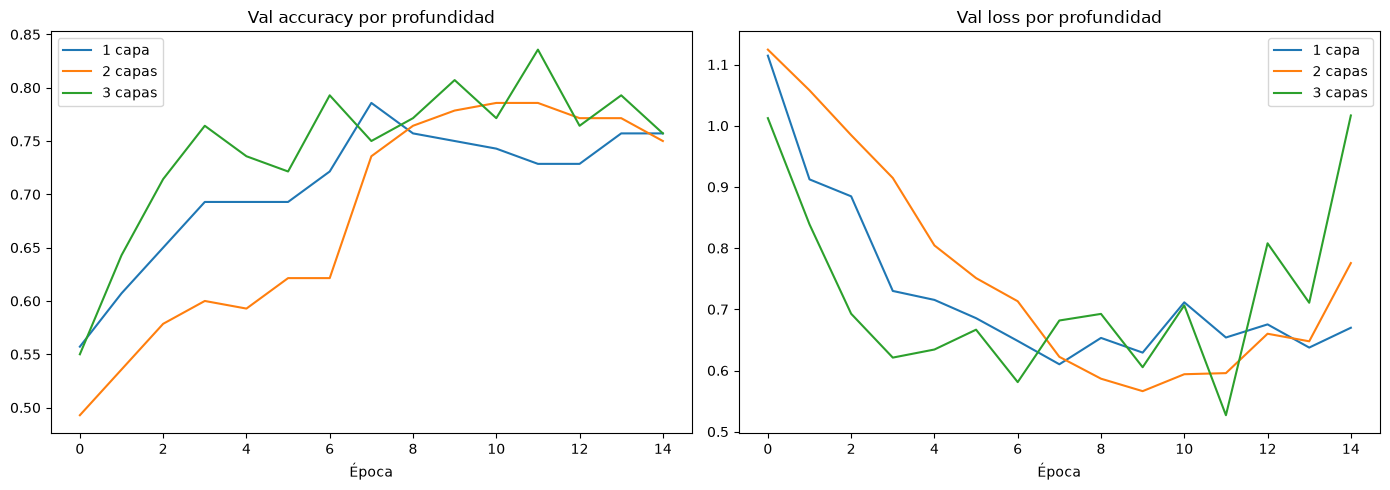

In [112]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for nombre, history in historiales.items():
    axes[0].plot(history.history["val_accuracy"], label=nombre)
    axes[1].plot(history.history["val_loss"], label=nombre)

axes[0].set_title("Val accuracy por profundidad")
axes[0].set_xlabel("Época")
axes[0].legend()

axes[1].set_title("Val loss por profundidad")
axes[1].set_xlabel("Época")
axes[1].legend()

plt.tight_layout()
plt.show()

Aumentar la profundidad de 1 a 3 capas no mejora consistentemente el accuracy final con este dataset, y de hecho la arquitectura más profunda (3 capas) es la más inestable durante el entrenamiento más varianza en accuracy y loss de validación entre épocas. Esto sugiere que, con solo ~655 imágenes de entrenamiento, el dataset no es lo suficientemente grande como para que una red más profunda aproveche su capacidad adicional de forma estable.

##### reporte

**Diseño del experimento**

Comparé 3 arquitecturas idénticas en todo, excepto en el número de bloques convolucionales (1, 2 y 3). Mantuve fijo el kernel (3x3), el stride (1), el padding ("same"), la activación (ReLU), el pooling (MaxPooling 2x2), el optimizador (Adam), las épocas (15) y el batch size (32).

**Resultados**

| Profundidad | Train accuracy | Val accuracy | Test accuracy | Test loss |
|---|---|---|---|---|
| 1 capa | 99.4% | 75.7% | 77.5% | 0.65 |
| 2 capas | 98.0% | 75.0% | 70.4% | 0.87 |
| 3 capas | 97.9% | 75.7% | 77.5% | 0.93 |

**Lo que observé**

Las 3 arquitecturas terminaron con un accuracy de validación muy parecido, entre 75% y 76%, sin que agregar más capas mejorara claramente el resultado. En test, la de 2 capas fue la que peor le fue (70.4%), mientras que 1 y 3 capas empataron en 77.5%. Pero el loss cuenta otra historia: el de 3 capas casi duplica el de 1 capa, lo que quiere decir que aunque acertó lo mismo, sus predicciones fueron menos seguras.

Durante el entrenamiento, la de 3 capas fue la más inestable: tuvo el pico más alto de las tres, pero también subió y bajó mucho más entre épocas, y su loss de validación terminó disparándose al final.

**Conclusión**

Aumentar la profundidad de 1 a 3 capas no mejora consistentemente el accuracy con este dataset, y la arquitectura más profunda (3 capas) resultó ser la más inestable durante el entrenamiento. Con solo ~655 imágenes de entrenamiento, el dataset parece no ser lo suficientemente grande como para que una red más profunda aproveche su capacidad extra de forma estable. Agregar más capas aquí no se tradujo en mejor generalización, solo en un modelo más costoso y más impredecible entre corridas.

##### **Interpretación y Razonamiento Arquitectónico**

**¿Por qué las capas convolucionales superaron (o no) al modelo base?**

Las capas convolucionales superaron al modelo base: el baseline llegó a 64.1% de accuracy en test, mientras que la CNN llegó a 81.7%. debido a que la convolución no aplana la imagen de entrada, mantiene la relación espacial entre píxeles vecinos, lo cual le permite reconocer patrones como manchas sin importar en qué parte de la hoja aparezcan. Mientras que en el modelo base, aplanaba la imagen desde el inicio, tratando cada píxel como un dato suelto, sin relación con sus vecinos, esto generaba muchísimos parámetros (3.1 millones) concentrados en la primera capa, y se presentaba el sobreajuste que vimos en las curvas de validación inestables. En la CNN, aplanar solo ocurre al final, después de que las capas convolucionales ya redujeron y resumieron la imagen en un mapa de características más pequeño, lo que ayuda a que el modelo generalice mejor.

**¿Qué sesgo inductivo introduce la convolución?**

La convolución ya trae dos supuestos, antes de ver algun dato. El primero es que los patrones importantes de una imagen están formados por píxeles vecinos, no sueltos, por eso el filtro solo mira un pedacito pequeño a la vez, no la imagen completa.

El segundo es que ese mismo filtro se repite por toda la imagen, así que si aprende a reconocer una mancha en una esquina, también la reconoce si aparece en el centro de otra foto. O sea, no importa en qué parte esté, el modelo igual la detecta.

Como las manchas de sigatoka, cordana o pestalotiopsis pueden salir en cualquier parte de la hoja, esto le favorece a mi dataset. El modelo base, en cambio, no tiene esa ventaja, mira cada píxel por separado, sin saber que están relacionados entre sí. Entonces le tocaba aprender eso solo, a punta de datos, y con apenas 655 imágenes no le alcanzó.

**¿En qué tipo de problemas no sería apropiada la convolución?**

La convolución deja de tener sentido cuando los datos no tienen esa estructura de "vecindad" como veniamos viendo en las preguntas anteriores. Por ejemplo, en el ejercicio pasado de enfermedades cardiacas con columnas de edad, presión y colesterol, cada columna significa algo fijo y distinto, no tiene sentido que un filtro deslizante busque el mismo patrón entre "edad y presión" que entre "presión y colesterol". Ahí es mejor una red densa, donde cada columna se trata por separado.

También falla en cosas donde lo que importa es la relación entre datos que están muy separados entre sí, no entre vecinos cercanos. Por ejemplo, si quiero predecir si alguien va a comprar algo según sus compras de los últimos 6 meses, lo que compró el primer mes puede ser tan importante como lo que compró la semana pasada, no importa que estén lejos en el tiempo. Aqui la convolución no ayuda tanto.

En resumen, la convolución funciona cuando la cercanía entre valores tiene significado (como en imágenes), pero no cuando cada valor tiene un significado fijo e independiente de su posición.